# FORS 

In [1]:
# If needed (uncomment):
# !pip install diffusers torch torchvision torchmetrics accelerate tqdm


In [2]:
import os
import time
from collections import defaultdict
from contextlib import nullcontext
from tqdm import tqdm

import torch
import numpy as np
import matplotlib.pyplot as plt

from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from fors_sampler import FORSSampler, FORSConfig

from tqdm import tqdm

In [ ]:
import os
import time
from collections import defaultdict
from contextlib import nullcontext

import torch
import numpy as np
import matplotlib.pyplot as plt

from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from fors_sampler import FORSSampler, FORSConfig
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_grad_enabled(False)

# Speed knobs
fast_mode = True
use_amp = (device == "cuda")

if device == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

model_id = "google/ddpm-celebahq-256"

# Default settings (fast_mode overrides below)
batch_size = 32
num_images = 1000
num_real = 2000
step_count = 100
fid_feature = 2048

if fast_mode:
    batch_size = 32
    num_images = 128
    num_real = 256
    step_count = 100
    fid_feature = 64

# FID requires at least 2 samples in each distribution
num_images = max(num_images, 2)
num_real = max(num_real, 2)

seed = 1234
torch.manual_seed(seed)

cache_dir = "./fid_cache"
os.makedirs(cache_dir, exist_ok=True)

def autocast_ctx():
    if use_amp:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


In [4]:
# need to modify so we have extremely high alpha and value at the end of the schedule,
# so that we can test the acceptance probability of the last few steps
# print(ddpm_sched)

In [5]:
unet = UNet2DModel.from_pretrained(model_id).to(device)
ddpm_sched = DDPMScheduler.from_pretrained(model_id, num_train_timesteps=step_count+1)
ddim_sched = DDIMScheduler.from_pretrained(model_id, num_train_timesteps=step_count+1)
# fors_sched = DDPMScheduler(beta_end=0.002, beta_start=0.00001, num_train_timesteps=step_count+1)
fors_sched = ddpm_sched

fors = FORSSampler(
    model=unet,
    scheduler=fors_sched,
    config=FORSConfig(B=1.0, max_resample=20),
    device=device,
)

in_channels = unet.config.in_channels
sample_size = unet.config.sample_size
if isinstance(sample_size, int):
    height = width = sample_size
else:
    height, width = sample_size


/home/kevin/anaconda3/envs/311/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [6]:
def sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

@torch.no_grad()
def sample_with_scheduler(unet, scheduler, num_inference_steps, batch_size, generator=None, eta=0.0):
    scheduler.set_timesteps(num_inference_steps)
    init_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
    x = torch.randn(
        (batch_size, in_channels, height, width),
        device=device,
        generator=generator,
    ) * init_sigma

    with autocast_ctx():
        for t in scheduler.timesteps:
            t_int = int(t)
            x_in = scheduler.scale_model_input(x, t_int)
            t_tensor = torch.full((x.shape[0],), t_int, device=device, dtype=torch.long)
            eps = unet(x_in, t_tensor).sample

            step_kwargs = {"generator": generator}
            if isinstance(scheduler, DDIMScheduler):
                step_kwargs["eta"] = eta
            x = scheduler.step(eps, t_int, x, **step_kwargs).prev_sample
    return x

def to_01(x):
    return (x.clamp(-1, 1) + 1) / 2


In [7]:
# CelebA real images (cached stats)
transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((height, width)),
    transforms.ToTensor(),
])

real_ds = datasets.CelebA(
    root="./data",
    split="test",
    download=True,
    transform=transform,
)

num_workers = min(8, (os.cpu_count() or 2) // 2)
real_loader = DataLoader(
    real_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

def add_real_images(fid_metric, n_real):
    count = 0
    for x, _ in real_loader:
        x = x.to(device, non_blocking=True)
        fid_metric.update(x, real=True)
        count += x.shape[0]
        if count >= n_real:
            break

def real_stats_cache_path():
    return os.path.join(
        cache_dir,
        f"celeba_real_stats_f{fid_feature}_n{num_real}_{height}x{width}.pt",
    )


def _state_num_samples(state, key):
    v = state.get(key, None)
    if v is None:
        return 0
    if torch.is_tensor(v):
        return int(v.item())
    return int(v)



def _metric_num_samples(metric, key):
    v = getattr(metric, key, None)
    if v is None:
        return 0
    if torch.is_tensor(v):
        return int(v.item())
    return int(v)


def load_or_compute_real_stats():
    path = real_stats_cache_path()
    if os.path.exists(path):
        state = torch.load(path, map_location="cpu")
        if _state_num_samples(state, "real_features_num_samples") >= 2:
            return state
        # stale/invalid cache

    fid = FrechetInceptionDistance(feature=fid_feature, normalize=True).to(device)
    add_real_images(fid, num_real)
    state = {k: v.cpu() for k, v in fid.state_dict().items()}
    torch.save(state, path)
    return state

real_state = load_or_compute_real_stats()


In [8]:
def init_fid_metrics(step_count):
    fids = {}
    for k in range(1, step_count + 1):
        fid = FrechetInceptionDistance(feature=fid_feature, normalize=True).to(device)
        fid.load_state_dict(real_state)
        if _metric_num_samples(fid, "real_features_num_samples") < 2:
            add_real_images(fid, num_real)
        fids[k] = fid
    return fids

def init_results_csv(path):
    with open(path, "w") as f:
        f.write("step,fid,time,img_per_sec,step_per_sec,sec_per_step\n")

def append_results_csv(path, step, fid_score, t_sample, img_per_sec, step_per_sec, sec_per_step):
    with open(path, "a") as f:
        f.write(
            f"{step},{fid_score:.6f},{t_sample:.6f},{img_per_sec:.6f},{step_per_sec:.6f},{sec_per_step:.6f}\n"
        )

@torch.no_grad()
def sample_stepwise_ddpm(unet, scheduler, num_inference_steps, batch_size, fid_map, generator=None, eta=0.0):
    scheduler.set_timesteps(num_inference_steps)
    init_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
    x = torch.randn(
        (batch_size, in_channels, height, width),
        device=device,
        generator=generator,
    ) * init_sigma

    step_times = {k: 0.0 for k in range(1, num_inference_steps + 1)}
    elapsed = 0.0
    with autocast_ctx():
        for i, t in enumerate(scheduler.timesteps, start=1):
            t0 = time.perf_counter()
            t_int = int(t)
            x_in = scheduler.scale_model_input(x, t_int)
            t_tensor = torch.full((x.shape[0],), t_int, device=device, dtype=torch.long)
            eps = unet(x_in, t_tensor).sample

            step_kwargs = {"generator": generator}
            if isinstance(scheduler, DDIMScheduler):
                step_kwargs["eta"] = eta
            x = scheduler.step(eps, t_int, x, **step_kwargs).prev_sample
            sync()
            elapsed += time.perf_counter() - t0

            fid_map[i].update(to_01(x), real=False)
            step_times[i] += elapsed
    return step_times

@torch.no_grad()
def sample_stepwise_fors(fors_sampler, num_steps, batch_size, fid_map, generator=None):
    # For FORS, use one extra timestep so we get exactly num_steps transitions
    fors_sampler.set_timesteps(num_steps + 1)
    timesteps = fors_sampler.timesteps
    t_start = int(timesteps[0])
    sigma_start = torch.sqrt(1.0 - fors_sampler.alphas_cumprod[t_start])
    x = torch.randn(
        (batch_size, in_channels, height, width),
        device=device,
        generator=generator,
        dtype=fors_sampler.alphas_cumprod.dtype,
    ) * sigma_start

    step_times = {k: 0.0 for k in range(1, num_steps + 1)}
    elapsed = 0.0
    with autocast_ctx():
        for i in range(len(timesteps) - 1):
            t0 = time.perf_counter()
            t_cur = int(timesteps[i])
            t_prev = int(timesteps[i + 1])
            x = fors_sampler._fors_step(x, t_cur, t_prev)
            sync()
            elapsed += time.perf_counter() - t0

            step_idx = i + 1
            fid_map[step_idx].update(to_01(x), real=False)
            step_times[step_idx] += elapsed
    return step_times


In [9]:
results = defaultdict(lambda: defaultdict(list))

step_indices = list(range(1, step_count + 1))
results_dir = os.path.join(cache_dir, "results")
os.makedirs(results_dir, exist_ok=True)

for name in ["fors", "ddpm", "ddim"]:
    fid_map = init_fid_metrics(step_count)
    time_map = {k: 0.0 for k in step_indices}

    count = 0
    batch_idx = 0
    pbar = tqdm(total=num_images, desc=f"{name} images")
    while count < num_images:
        bs = min(batch_size, num_images - count)
        gen = torch.Generator(device=device).manual_seed(seed + batch_idx)
        if name == "ddpm":
            step_times = sample_stepwise_ddpm(unet, ddpm_sched, step_count, bs, fid_map, generator=gen)
        elif name == "ddim":
            step_times = sample_stepwise_ddpm(unet, ddim_sched, step_count, bs, fid_map, generator=gen, eta=0.0)
        else:
            step_times = sample_stepwise_fors(fors, step_count, bs, fid_map, generator=gen)
        for k in step_indices:
            time_map[k] += step_times[k]
        count += bs
        batch_idx += 1
        pbar.update(bs)
    pbar.close()

    csv_path = os.path.join(results_dir, f"{name}_steps{step_count}_n{num_images}_f{fid_feature}.csv")
    init_results_csv(csv_path)

    for k in step_indices:
        fid = fid_map[k]
        if _metric_num_samples(fid, "fake_features_num_samples") < 2:
            raise RuntimeError("Not enough fake samples to compute FID. Increase num_images.")
        fid_score = float(fid.compute().cpu())
        t_sample = time_map[k]

        img_per_sec = num_images / max(t_sample, 1e-9)
        step_per_sec = (num_images * k) / max(t_sample, 1e-9)
        sec_per_step = t_sample / max(num_images * k, 1e-9)

        results[name]["fid"].append(fid_score)
        results[name]["time"].append(t_sample)
        results[name]["img_per_sec"].append(img_per_sec)
        results[name]["step_per_sec"].append(step_per_sec)
        results[name]["sec_per_step"].append(sec_per_step)

        append_results_csv(csv_path, k, fid_score, t_sample, img_per_sec, step_per_sec, sec_per_step)

        print(
            f"steps={k:>3}  sampler={name:>4}  FID={fid_score:>7.2f}  "
            f"time={t_sample:>7.2f}s  imgs/s={img_per_sec:>7.2f}  step/s={step_per_sec:>9.2f}"
        )


fors images: 100%|██████████| 128/128 [07:08<00:00,  3.35s/it]

steps=  1  sampler=fors  FID= 231.38  time=  23.65s  imgs/s=   5.41  step/s=     5.41
steps=  2  sampler=fors  FID= 223.50  time=  37.49s  imgs/s=   3.41  step/s=     6.83
steps=  3  sampler=fors  FID= 211.75  time=  53.12s  imgs/s=   2.41  step/s=     7.23
steps=  4  sampler=fors  FID= 204.12  time=  69.48s  imgs/s=   1.84  step/s=     7.37
steps=  5  sampler=fors  FID= 193.50  time=  87.65s  imgs/s=   1.46  step/s=     7.30
steps=  6  sampler=fors  FID= 186.62  time= 106.45s  imgs/s=   1.20  step/s=     7.21
steps=  7  sampler=fors  FID= 177.25  time= 123.36s  imgs/s=   1.04  step/s=     7.26
steps=  8  sampler=fors  FID= 170.25  time= 140.31s  imgs/s=   0.91  step/s=     7.30
steps=  9  sampler=fors  FID= 161.00  time= 157.91s  imgs/s=   0.81  step/s=     7.30
steps= 10  sampler=fors  FID= 154.62  time= 175.07s  imgs/s=   0.73  step/s=     7.31
steps= 11  sampler=fors  FID= 146.38  time= 193.32s  imgs/s=   0.66  step/s=     7.28
steps= 12  sampler=fors  FID= 140.88  time= 213.19s  i


ddpm images: 100%|██████████| 128/128 [00:46<00:00,  2.75it/s]

steps=  1  sampler=ddpm  FID= 432.50  time=   2.33s  imgs/s=  54.87  step/s=    54.87
steps=  2  sampler=ddpm  FID= 428.00  time=   4.66s  imgs/s=  27.47  step/s=    54.94
steps=  3  sampler=ddpm  FID= 419.00  time=   6.99s  imgs/s=  18.32  step/s=    54.96
steps=  4  sampler=ddpm  FID= 411.25  time=   9.31s  imgs/s=  13.74  step/s=    54.97
steps=  5  sampler=ddpm  FID= 403.00  time=  11.64s  imgs/s=  11.00  step/s=    54.98
steps=  6  sampler=ddpm  FID= 391.75  time=  13.97s  imgs/s=   9.16  step/s=    54.98
steps=  7  sampler=ddpm  FID= 379.75  time=  16.30s  imgs/s=   7.85  step/s=    54.98
steps=  8  sampler=ddpm  FID= 364.75  time=  18.62s  imgs/s=   6.87  step/s=    54.98
steps=  9  sampler=ddpm  FID= 348.00  time=  20.95s  imgs/s=   6.11  step/s=    54.98
steps= 10  sampler=ddpm  FID= 329.00  time=  23.28s  imgs/s=   5.50  step/s=    54.98
steps= 11  sampler=ddpm  FID= 310.00  time=  25.61s  imgs/s=   5.00  step/s=    54.98
steps= 12  sampler=ddpm  FID= 295.00  time=  27.94s  i


ddim images: 100%|██████████| 128/128 [00:46<00:00,  2.74it/s]

steps=  1  sampler=ddim  FID= 437.75  time=   2.33s  imgs/s=  54.93  step/s=    54.93
steps=  2  sampler=ddim  FID= 433.00  time=   4.66s  imgs/s=  27.47  step/s=    54.94
steps=  3  sampler=ddim  FID= 433.75  time=   6.99s  imgs/s=  18.32  step/s=    54.96
steps=  4  sampler=ddim  FID= 426.50  time=   9.32s  imgs/s=  13.74  step/s=    54.96
steps=  5  sampler=ddim  FID= 420.75  time=  11.64s  imgs/s=  10.99  step/s=    54.96
steps=  6  sampler=ddim  FID= 418.00  time=  13.97s  imgs/s=   9.16  step/s=    54.96
steps=  7  sampler=ddim  FID= 411.75  time=  16.30s  imgs/s=   7.85  step/s=    54.96
steps=  8  sampler=ddim  FID= 410.50  time=  18.63s  imgs/s=   6.87  step/s=    54.96
steps=  9  sampler=ddim  FID= 402.75  time=  20.96s  imgs/s=   6.11  step/s=    54.96
steps= 10  sampler=ddim  FID= 394.75  time=  23.29s  imgs/s=   5.50  step/s=    54.96
steps= 11  sampler=ddim  FID= 386.00  time=  25.62s  imgs/s=   5.00  step/s=    54.96
steps= 12  sampler=ddim  FID= 381.25  time=  27.95s  i

In [ ]:
# plot FID vs Time

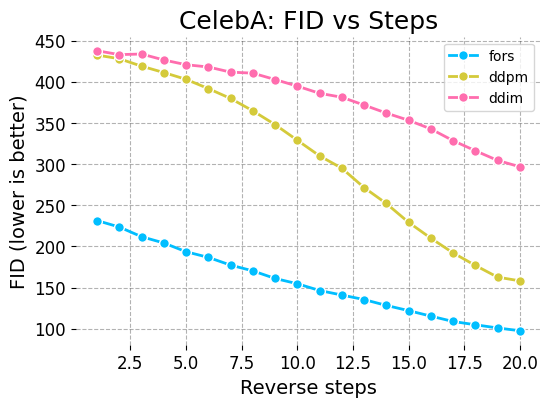

In [10]:
plt.figure(figsize=(6, 4))
for name, scores in results.items():
    plt.plot(step_indices, scores["fid"], marker="o", label=name)

plt.xlabel("Reverse steps")
plt.ylabel("FID (lower is better)")
plt.title("CelebA: FID vs Steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


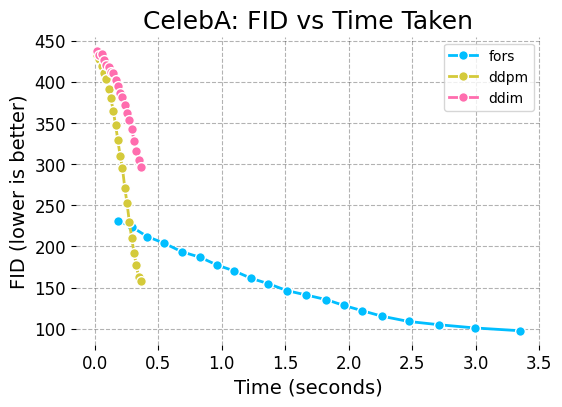

In [18]:
plt.figure(figsize=(6, 4))
for name, scores in results.items():
    plt.plot(np.array(step_indices) * scores["sec_per_step"], scores["fid"], marker="o", label=name)

plt.xlabel("Time (seconds)")
plt.ylabel("FID (lower is better)")
plt.title("CelebA: FID vs Time Taken")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


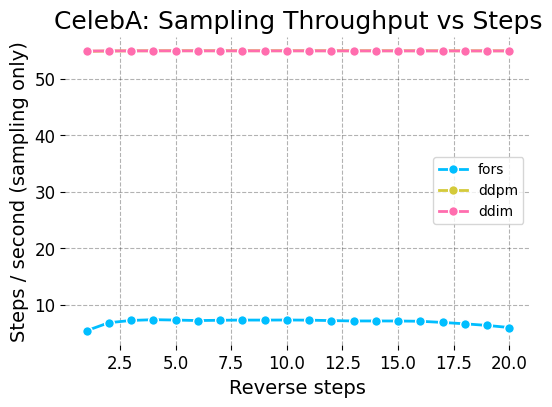

In [11]:
plt.figure(figsize=(6, 4))
for name, scores in results.items():
    plt.plot(step_indices, scores["step_per_sec"], marker="o", label=name)

plt.xlabel("Reverse steps")
plt.ylabel("Steps / second (sampling only)")
plt.title("CelebA: Sampling Throughput vs Steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


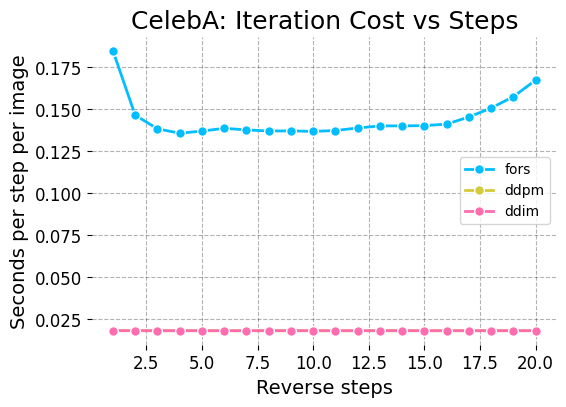

In [12]:
plt.figure(figsize=(6, 4))
for name, scores in results.items():
    plt.plot(step_indices, scores["sec_per_step"], marker="o", label=name)

plt.xlabel("Reverse steps")
plt.ylabel("Seconds per step per image")
plt.title("CelebA: Iteration Cost vs Steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
